# EDA - Using matched treatment and control groups only

## Check summary_season_2 matching

In [1]:
import matplotlib.pyplot as plt
import warnings
import pandas as pd
warnings.filterwarnings("ignore")

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, 3, Finished, Available, Finished, False)

In [2]:
%run ./consumption_plot

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, 4, Finished, Available, Finished, True)

In [3]:
%run ./peak_plot

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, 5, Finished, Available, Finished, True)

In [4]:
%run ./consumption_cohort

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, 6, Finished, Available, Finished, True)

## Load Data 

### Adopt matching result

In [5]:
# Change here !!!
match_method = "summary_season_2"

# option: calendar, calendar2, summary_1, summary_2, summary_3, summary_4, summary_season, summary_season_2, time_series
# check: time_series, calendar(matching result is not that good), summary_4, summary_season_2

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, 7, Finished, Available, Finished, False)

In [6]:
matches = pd.read_parquet(f"/lakehouse/default/Files/output/matching/{match_method}/matches")
print(matches.head())

treated_ids = matches["treated_id"].unique()
control_ids = matches["control_id"].unique()
print(f"Treated IDs: {len(treated_ids)}, Control IDs: {len(control_ids)}")

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, 8, Finished, Available, Finished, False)

FileNotFoundError: [Errno 2] No such file or directory: '/lakehouse/default/Files/output/matching/summary_season_2/matches'

### Consumption data

In [ ]:
month_result= pd.read_parquet("/lakehouse/default/Files/month_data")
print(month_result.shape)

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

In [ ]:
# Consumption data
month_result["treatment"] = None
month_result.loc[month_result["aID"].isin(treated_ids), "treatment"] = 1
month_result.loc[month_result["aID"].isin(control_ids), "treatment"] = 0
month_result = month_result[month_result["treatment"].notna()]
print(month_result.shape)
month_result.head()

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

## Electricity data

In [ ]:
# month
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    show_legend=False
)

plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["tariff_active"],
)

plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["tariff_active"],
    exclude_future_tariff=True
)

plot_tariff_adoption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption"
)

plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["price","tariff_active"]
)

plot_consumption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["price","tariff_active"],
    exclude_future_tariff=True
)

plot_tariff_adoption(
    month_result,
    group_by="month",
    value_col="top3_mean_consumption",
    by_price=True
)

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

In [ ]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group"]
)

plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group", "tariff_active"],
    facet_by="usage_group"
)

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

In [ ]:
plot_consumption(
    month_result[month_result["price"] == "all"],
    group_by="month",
    value_col="top3_mean_consumption",
    splits=["usage_group", "tariff_active"],
    exclude_future_tariff=True,
    facet_by="usage_group"
)

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

In [ ]:
plot_tariff_adoption_by_usage(
    month_result[month_result["price"] == "all"],
    figsize=(6, 4)
)

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

In [ ]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

In [ ]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

In [ ]:
# 有選 tariff 的人的用電量平均變化 (按用電總量分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    line_cols="usage_group",
    window=12
)

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

In [ ]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

In [ ]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

In [ ]:
# 有選 tariff 的人的用電量平均變化 (按tariff plan 分組)
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    line_cols="tariff_plan",
    window=12
)

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

In [ ]:
# 有選 tariff 的人的用電量平均變化
plot_event_study_tariff(
    month_result[month_result["price"] == "all"],
    value_col="top3_mean_consumption",
    window=12
)

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

In [ ]:
# 有選 tariff 的人的用電量平均變化
plot_event_study_tariff(
    month_result[month_result["price"] == "high"],
    value_col="top3_mean_consumption",
    window=12
)

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

In [ ]:
# 有選 tariff 的人的用電量平均變化
plot_event_study_tariff(
    month_result[month_result["price"] == "low"],
    value_col="top3_mean_consumption",
    window=12
)

StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

In [ ]:
# Peak hour distribution (count)
# 看 peak 最常發生在一天的哪個小時
plot_peak_hour_distribution(month_result[month_result["price"] == "high"])

# Peak hour distribution (consumption)
# 看哪個小時的 peak 用電量總和最高（電網壓力）
plot_peak_hour_distribution(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

# Peak heatmap (count)
# Month × Hour heatmap，看不同月份 peak 最常出現的時間
plot_peak_heatmap(month_result[month_result["price"] == "high"])

# Peak heatmap (consumption)
# Month × Hour heatmap，但用顏色表示 peak 用電量
plot_peak_heatmap(
    month_result[month_result["price"] == "high"],
    mode="consumption"
)

# Peak consumption distribution
# Histogram，看 peak demand 的大小分布（household peak size）
plot_peak_consumption_distribution(
    month_result[month_result["price"] == "high"]
)

# Peak rank boxplot
# 比較 peak1 / peak2 / peak3 的用電量分布，看 spike 程度
plot_peak_rank_boxplot(
    month_result[month_result["price"] == "high"]
)

# Peak timing heatmap: P(hour | peak)
# 比較 tariff 前後 peak 發生次數的 Month × Hour heatmap
plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "high"],
    price_label="high"
)

# # Peak consumption heatmap: E(consumption | peak hour)
plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "high"],
    price_label="high"
)


StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

In [ ]:
# Overall peak analysis
# Peak hour distribution (count)
plot_peak_hour_distribution(month_result[month_result["price"] == "all"])

# Peak hour distribution (consumption)
plot_peak_hour_distribution(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

# Peak heatmap (count)
plot_peak_heatmap(month_result[month_result["price"] == "all"])

# Peak heatmap (consumption)
plot_peak_heatmap(
    month_result[month_result["price"] == "all"],
    mode="consumption"
)

# Peak consumption distribution
plot_peak_consumption_distribution(
    month_result[month_result["price"] == "all"]
)

# Peak rank boxplot
plot_peak_rank_boxplot(
    month_result[month_result["price"] == "all"]
)

# Peak timing heatmap: P(hour | peak)
plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "all"], 
    price_label="all"
)

# # Peak consumption heatmap: E(consumption | peak hour)
plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "all"],
    price_label="all"
)


StatementMeta(, 0901a5ff-ed16-4a3c-9be3-f1d80e4f4a07, -1, Cancelled, , Cancelled, True)

In [ ]:
# Low peak analysis
# Peak hour distribution (count)
plot_peak_hour_distribution(month_result[month_result["price"] == "low"])

# Peak hour distribution (consumption)
plot_peak_hour_distribution(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)

# Peak heatmap (count)
plot_peak_heatmap(month_result[month_result["price"] == "low"])

# Peak heatmap (consumption)
plot_peak_heatmap(
    month_result[month_result["price"] == "low"],
    mode="consumption"
)

# Peak consumption distribution
plot_peak_consumption_distribution(
    month_result[month_result["price"] == "low"]
)

# Peak rank boxplot
plot_peak_rank_boxplot(
    month_result[month_result["price"] == "low"]
)

# Peak timing heatmap: P(hour | peak)
plot_tariff_peak_heatmap(
    month_result[month_result["price"] == "low"],
    price_label="low"
)


# # Peak consumption heatmap: E(consumption | peak hour)
plot_tariff_consumption_heatmap(
    month_result[month_result["price"] == "low"],
    price_label="low"
)


## Look at specific month

In [25]:
# plot_cohort_calendar(
#     month_result[month_result["price"] == "all"],
#     cohort_month="2025-03"
# )
# plot_cohort_calendar(
#     month_result[month_result["price"] == "all"],
#     cohort_month="2025-04"
# )

StatementMeta(, 66f969ad-5ed7-4a67-9847-ff98c57cc2db, 27, Finished, Available, Finished, False)

StatementMeta(, 66f969ad-5ed7-4a67-9847-ff98c57cc2db, 28, Finished, Available, Finished, False)

<Axes: title={'center': 'Average Peak Consumption by Tariff Adoption Month'}, xlabel='Month', ylabel='Average Consumption (kWh)'>

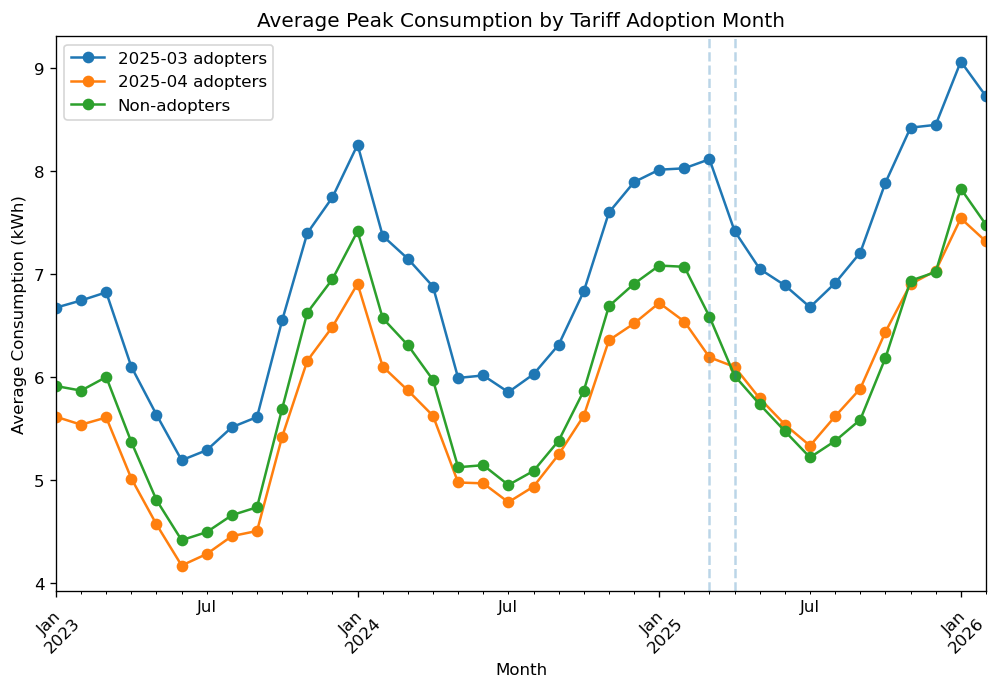

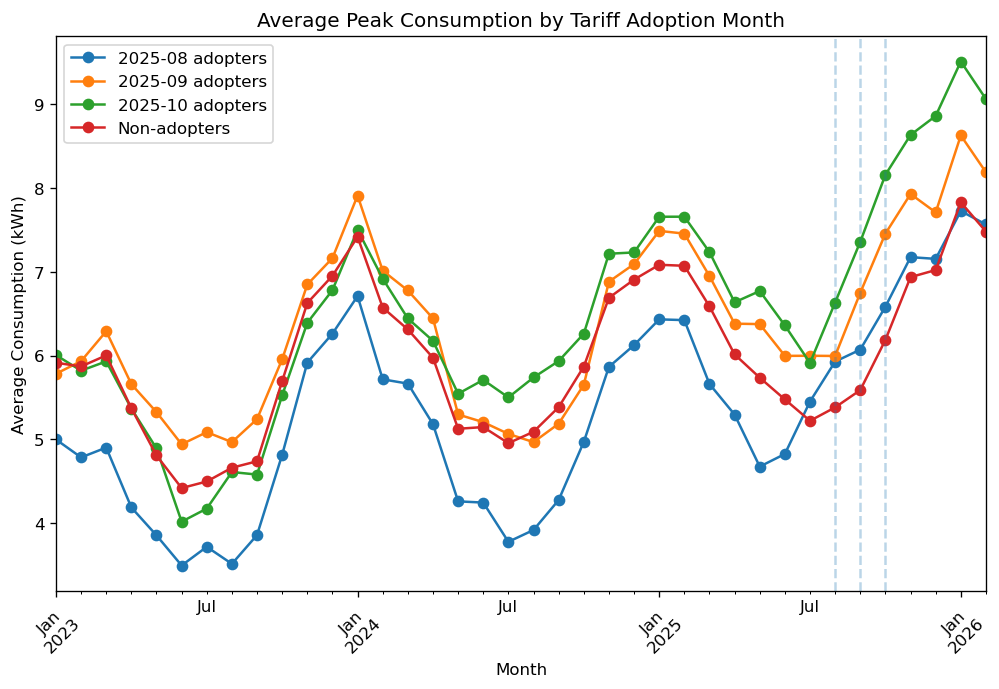

In [26]:
plot_multiple_cohorts(
    month_result[month_result["price"] == "all"],
    cohort_months=["2025-03", "2025-04", ]
)

plot_multiple_cohorts(
    month_result[month_result["price"] == "all"],
    cohort_months=["2025-08", "2025-09", "2025-10"]
)

StatementMeta(, 66f969ad-5ed7-4a67-9847-ff98c57cc2db, 29, Finished, Available, Finished, False)

array([<Axes: title={'center': 'Mar 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Apr 2025 adopters'}, xlabel='TIDPUNKT'>,
       <Axes: title={'center': 'May 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Jun 2025 adopters'}, xlabel='TIDPUNKT'>,
       <Axes: title={'center': 'Jul 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Aug 2025 adopters'}, xlabel='TIDPUNKT'>,
       <Axes: title={'center': 'Sep 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Oct 2025 adopters'}, xlabel='TIDPUNKT'>,
       <Axes: title={'center': 'Nov 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Dec 2025 adopters'}, xlabel='TIDPUNKT'>],
      dtype=object)

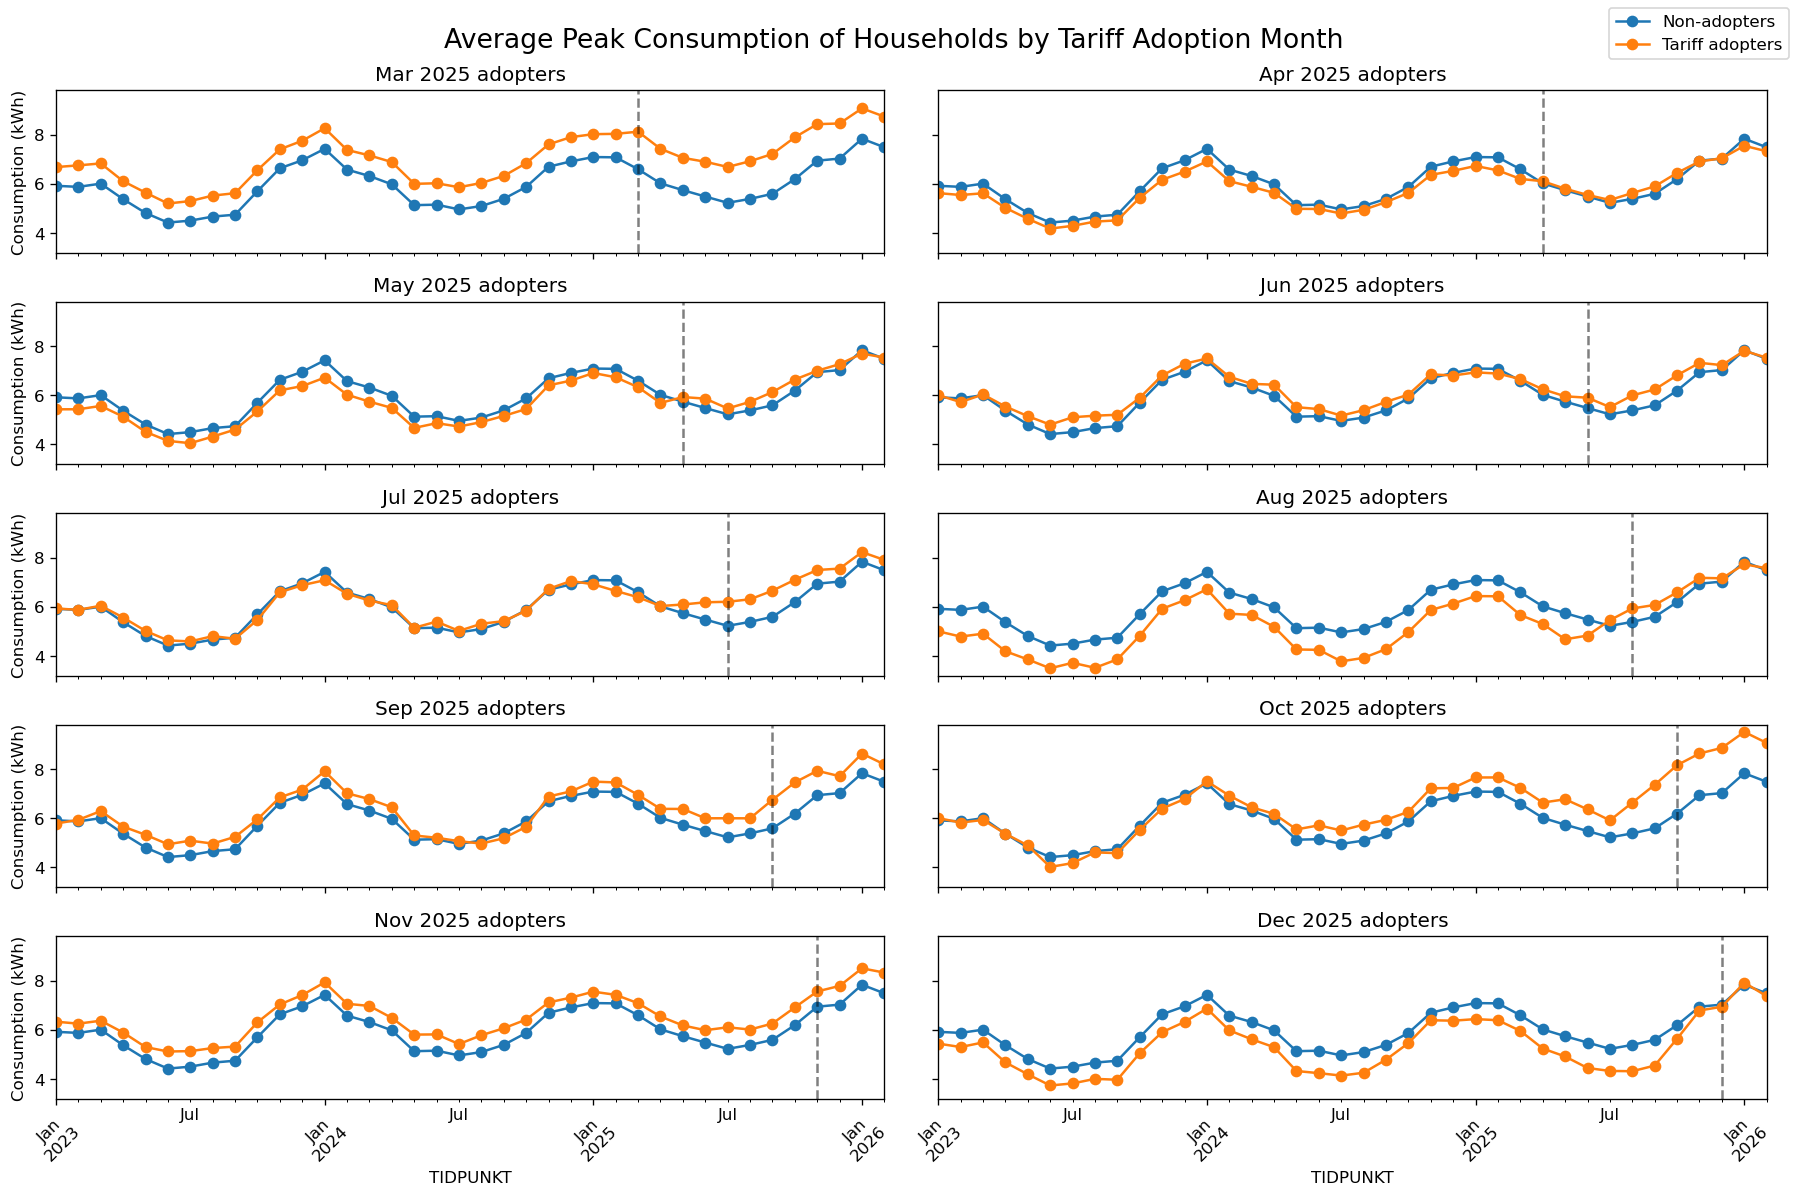

In [27]:
plot_cohort_panels(
    month_result[month_result["price"] == "all"],
    cohort_months=[
        "2025-03", "2025-04", "2025-05",
        "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12"
    ],
    ncols=2
)

StatementMeta(, 66f969ad-5ed7-4a67-9847-ff98c57cc2db, 30, Finished, Available, Finished, False)

array([<Axes: title={'center': 'Mar 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Apr 2025 adopters'}, xlabel='TIDPUNKT'>,
       <Axes: title={'center': 'May 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Jun 2025 adopters'}, xlabel='TIDPUNKT'>,
       <Axes: title={'center': 'Jul 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Aug 2025 adopters'}, xlabel='TIDPUNKT'>,
       <Axes: title={'center': 'Sep 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Oct 2025 adopters'}, xlabel='TIDPUNKT'>,
       <Axes: title={'center': 'Nov 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Dec 2025 adopters'}, xlabel='TIDPUNKT'>],
      dtype=object)

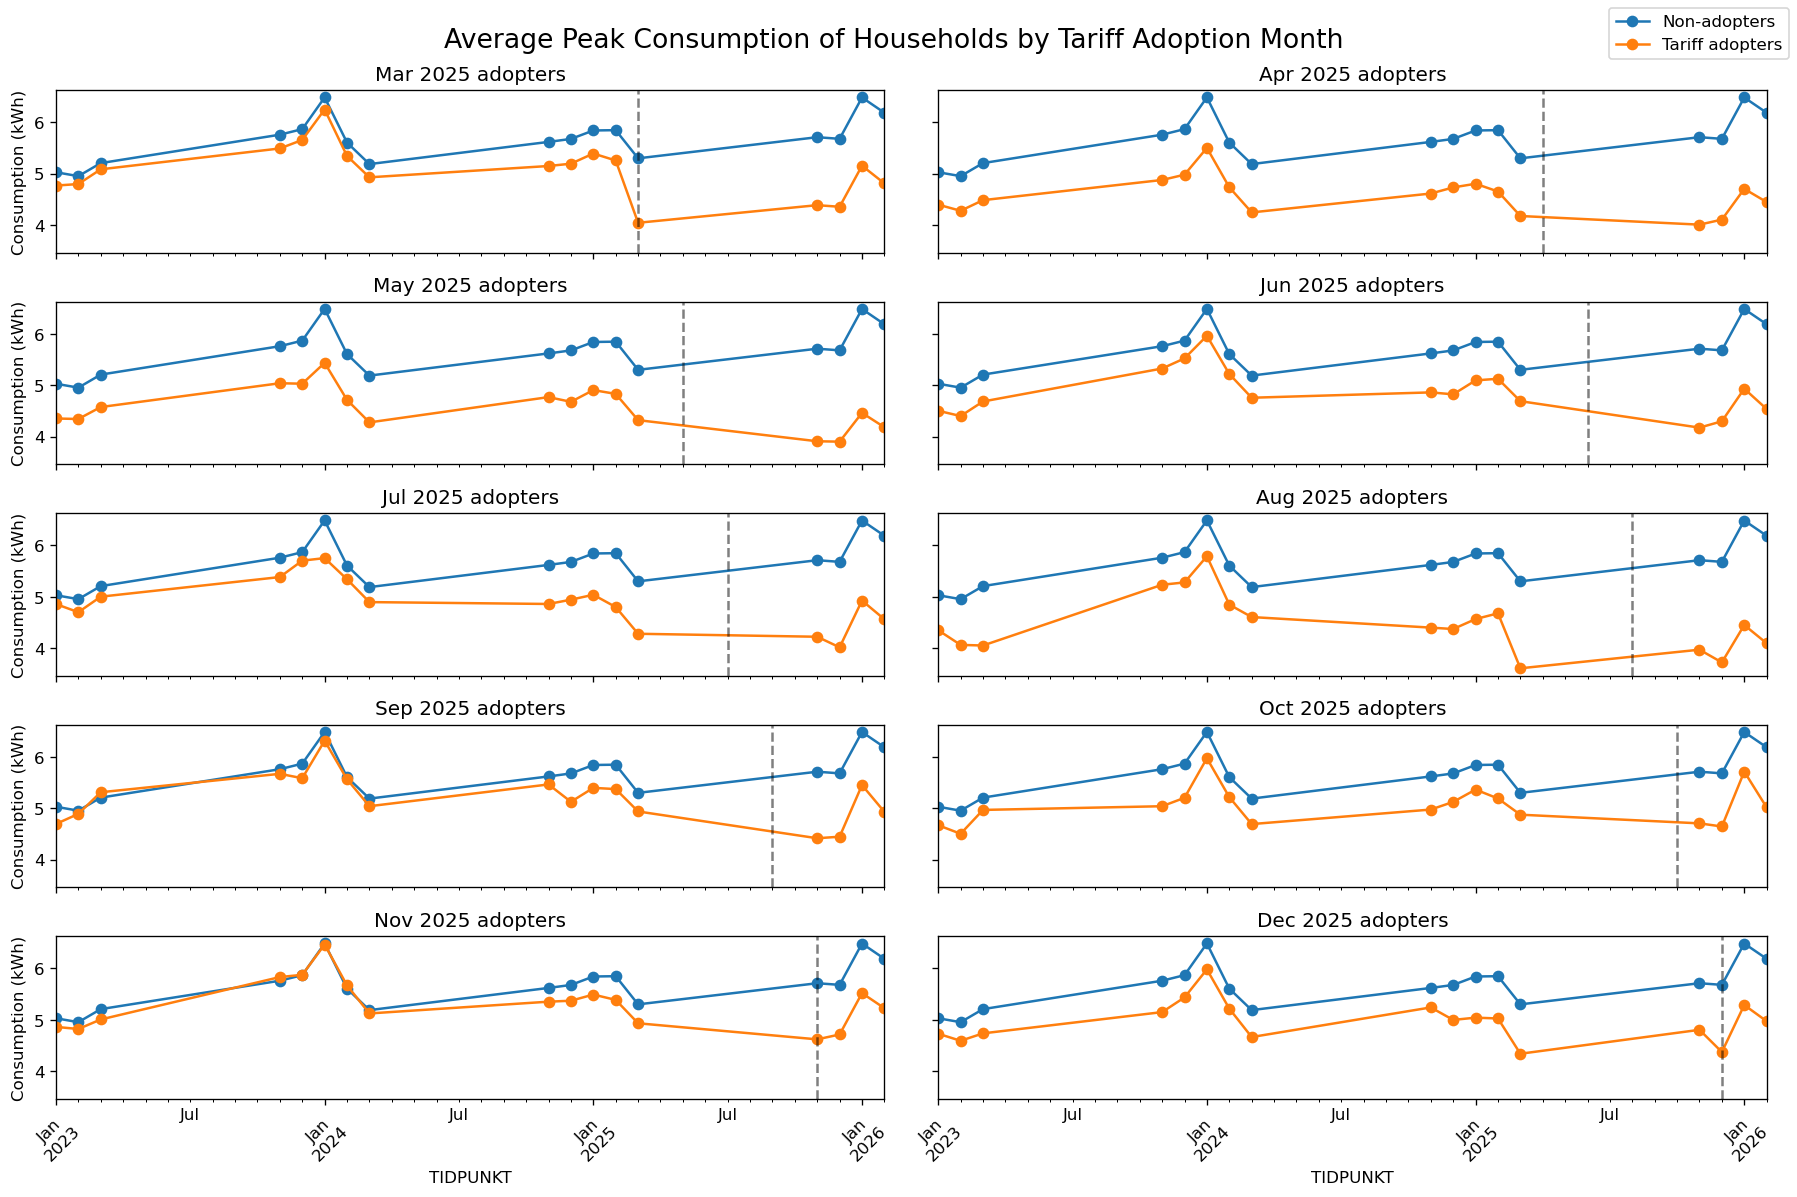

In [28]:
plot_cohort_panels(
    month_result[month_result["price"] == "high"],
    cohort_months=[
        "2025-03", "2025-04", "2025-05",
        "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12"
    ],
    ncols=2
)

StatementMeta(, 66f969ad-5ed7-4a67-9847-ff98c57cc2db, 31, Finished, Available, Finished, False)

array([<Axes: title={'center': 'Mar 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Apr 2025 adopters'}, xlabel='TIDPUNKT'>,
       <Axes: title={'center': 'May 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Jun 2025 adopters'}, xlabel='TIDPUNKT'>,
       <Axes: title={'center': 'Jul 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Aug 2025 adopters'}, xlabel='TIDPUNKT'>,
       <Axes: title={'center': 'Sep 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Oct 2025 adopters'}, xlabel='TIDPUNKT'>,
       <Axes: title={'center': 'Nov 2025 adopters'}, xlabel='TIDPUNKT', ylabel='Consumption (kWh)'>,
       <Axes: title={'center': 'Dec 2025 adopters'}, xlabel='TIDPUNKT'>],
      dtype=object)

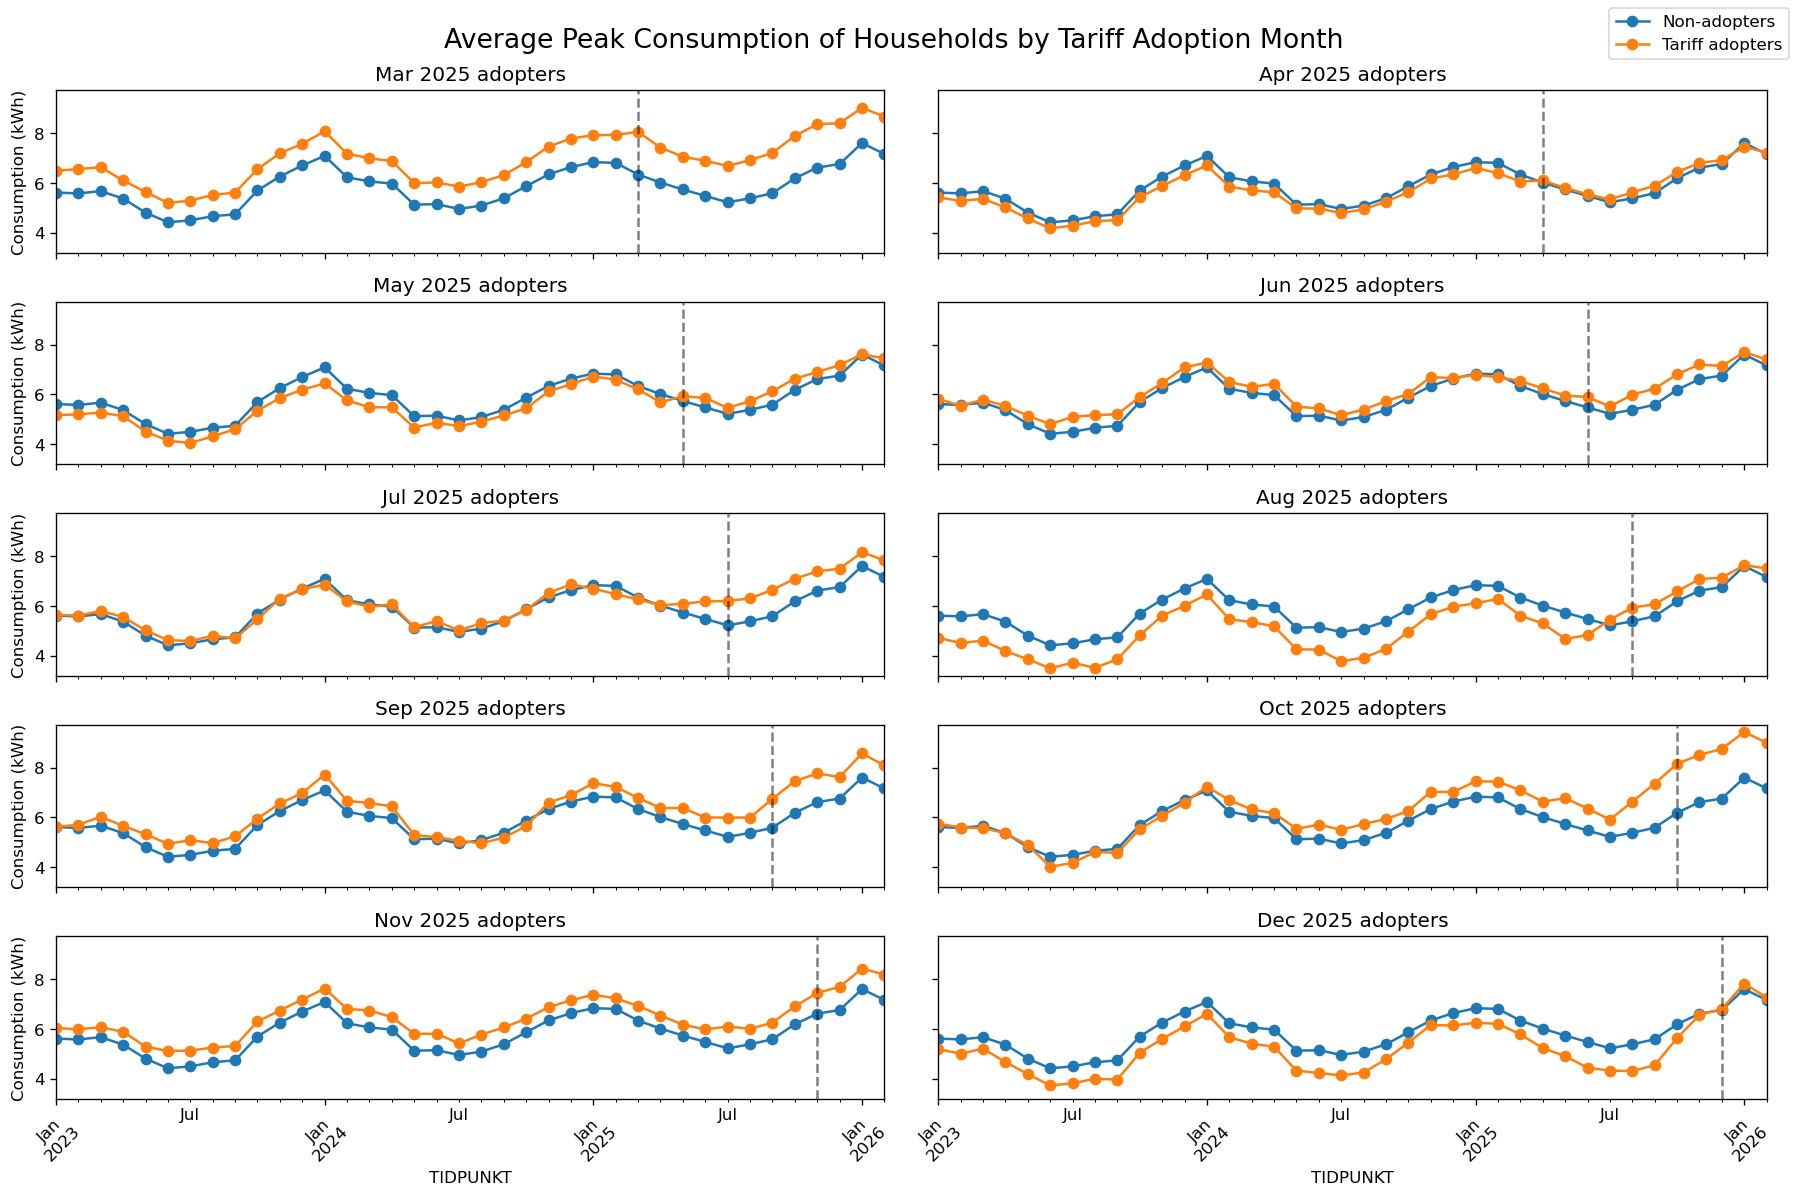

In [29]:
plot_cohort_panels(
    month_result[month_result["price"] == "low"],
    cohort_months=[
        "2025-03", "2025-04", "2025-05",
        "2025-06", "2025-07", "2025-08",
        "2025-09", "2025-10", "2025-11", "2025-12"
    ],
    ncols=2
)